# **Heart Attack Risk Prediction - Random Forest Classifier**
## *Model Training*

This project focuses on developing a supervised classification model to predict heart disease risk using clinical and lifestyle features.

### Kaggle dataset: [Heart Attack Risk Prediction Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/heart-attack-prediction-dataset)


First, please load the needed packages and modules into Python. Next, load the data into a pandas dataframe for ease of use.

In [11]:
import os
import pandas as pd
from datetime import datetime,timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import plotly.graph_objects as go
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/verahjd/heart-attack-risk-model/main/data/heart_attack_prediction_dataset.csv"
df = pd.read_csv(url)
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [13]:
df.shape


(8763, 26)

# Data Preprocessing
The goal of the following code blocks are to remove any unnecessary columns, normalization of data format.


###1. Drop unnecessary columns

In [14]:
df = df.drop(['Patient ID', 'Country', 'Continent', 'Hemisphere'],axis =1)
df.shape

(8763, 22)

###2. Check for missing values per column

*   List item
*   List item



In [15]:
df.isnull().sum()

,0
Age,0
Sex,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Smoking,0
Obesity,0
Alcohol Consumption,0


As see, there are no missing values. therefore we can move forward.

###3. Transform object data types to 'Dummy Features'

*Note: Dummy features are just a way to convert categorical text values into numbers so the model can actually do math on them.*

First, check column data types to identify objects

In [16]:
# Column Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Sex                              8763 non-null   object 
 2   Cholesterol                      8763 non-null   int64  
 3   Blood Pressure                   8763 non-null   object 
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Diet                             8763 non-null   object 
 12  Previous Heart Probl

Identified object datatypes:
a. Sex
b. Blood Pressure
c. Diet

Now, the goal is to change the values of Sex and Diet to numerical values.

In [17]:
df['Sex'] = df['Sex'].str.strip().map({'Male': 1, 'Female': 0})
df['Diet'] = df['Diet'].str.strip().map({'Unhealthy': 0, 'Average': 1, 'Healthy': 2})

df[['Sex', 'Diet']].head()

,Sex,Diet
0,1,1
1,1,0
2,0,2
3,1,1
4,1,0


Next, feature engineer the blood pressure object to create systolic and diastolic integers.

In [18]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop('Blood Pressure', axis=1).astype(int)

df[['Systolic', 'Diastolic']].head()

,Systolic,Diastolic
0,158,88
1,165,93
2,174,99
3,163,100
4,91,88


Validate if all object variables have been encoded to be numerical

In [19]:
dfo = df.select_dtypes(include=['object'], exclude=['datetime'])
dfo.shape

(8763, 0)

###4. Plot the correlation heat map for the features.

This is to determine which features are relevant to detemining heart attack risk


<Axes: title={'center': 'Correlation Heatmap for the Features'}>

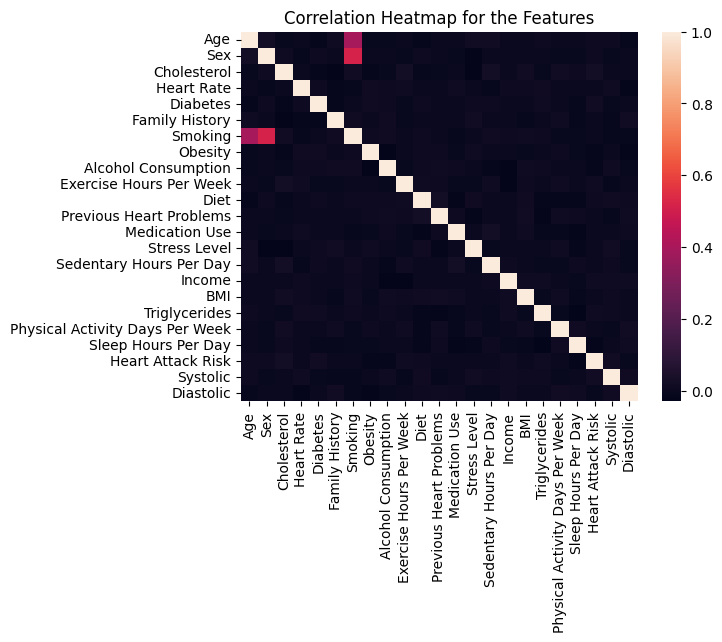

In [20]:
plt.title('Correlation Heatmap for the Features')
sns.heatmap(df.corr())

In [21]:
correlations = df.corr()['Heart Attack Risk'].sort_values(ascending=False)
print(correlations)

Heart Attack Risk                  1.000000
Cholesterol                        0.019340
Systolic                           0.018585
Diabetes                           0.017225
Exercise Hours Per Week            0.010862
Triglycerides                      0.010471
Income                             0.009628
Age                                0.006403
Diet                               0.005908
Sex                                0.003095
Medication Use                     0.002234
BMI                                0.000393
Previous Heart Problems            0.000274
Family History                    -0.001652
Smoking                           -0.004051
Stress Level                      -0.004111
Heart Rate                        -0.004251
Sedentary Hours Per Day           -0.004820
Physical Activity Days Per Week   -0.005014
Diastolic                         -0.007509
Obesity                           -0.013318
Alcohol Consumption               -0.013778
Sleep Hours Per Day             

*Note: panda's correlation allows us to check the relationship of a feature to its targat variable. 1 indicates a strong relationship. Since none of the variables closer to zero, they're not strongly related.*

### 5. Check for outliers

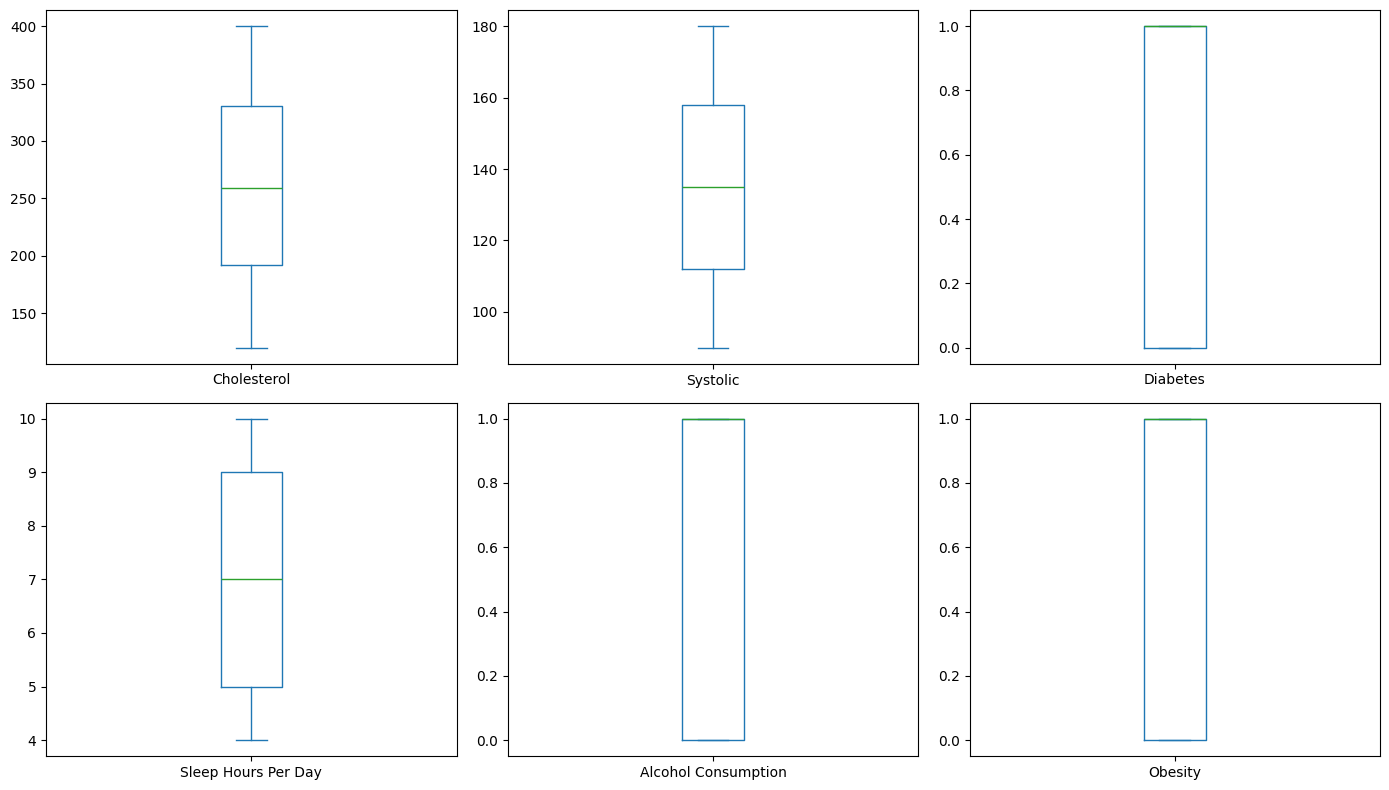

In [22]:
cols_to_check = ['Cholesterol', 'Systolic', 'Diabetes', 'Sleep Hours Per Day', 'Alcohol Consumption', 'Obesity']
df[cols_to_check].plot(kind='box', subplots=True, layout=(2,3), figsize=(14,8))
plt.tight_layout()
plt.show()

# Split the data into test and train subsamples

Features and the target variable is first separated into X and Y respectively.

In [23]:
from sklearn.model_selection import train_test_split

# Define x and y
x = df.drop('Heart Attack Risk', axis = 1)
y = df['Heart Attack Risk']

# Display raw features
x.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Systolic,Diastolic
0,67,1,208,72,0,0,1,0,0,4,...,0,9,6,261404,31,286,0,6,158,88
1,21,1,389,98,1,1,1,1,1,1,...,0,1,4,285768,27,235,1,7,165,93
2,21,0,324,72,1,0,0,0,0,2,...,1,9,9,235282,28,587,4,4,174,99
3,84,1,383,73,1,1,1,0,1,9,...,0,9,7,125640,36,378,3,4,163,100
4,66,1,318,93,1,1,1,1,0,5,...,0,6,1,160555,21,231,1,5,91,88


In [24]:
# Display target variable
y.head()

,Heart Attack Risk
0,0
1,0
2,0
3,0
4,0


Train-Test Split (80/20)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (7010, 22)
X_test shape: (1753, 22)


# Feature Scaling
Scale data to prepare for model creation

In [26]:
#scale data
from sklearn import preprocessing
import numpy as np

# build scaler based on training data and apply it to test data to then also scale the test data

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Fit Random Forest Classifier

In [27]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [28]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=300, random_state = 1,n_jobs=-1)
model_res = clf.fit(X_train_scaled, y_train)
y_pred = model_res.predict(X_test_scaled)
y_pred_prob = model_res.predict_proba(X_test_scaled)
lr_probs = y_pred_prob[:,1]
ac = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)


print('Random Forest: Accuracy=%.3f' % (ac))

print('Random Forest: f1-score=%.3f' % (f1))

print('Random Forest: Recall=%.3f' % (recall))

Random Forest: Accuracy=0.637
Random Forest: f1-score=0.502
Random Forest: Recall=0.003


In [29]:
print(y_train.value_counts(normalize=True))

Heart Attack Risk
0    0.641797
1    0.358203
Name: proportion, dtype: float64
